## Roughness scaling: equivalent roughness vs spatial average

_Normalize roughness contrast; vary spatial pattern (band, v-band) and storm characteristics._


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import shutil
import itertools as it
import contextlib
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
import statsmodels.formula.api as smf
import json
from scipy.stats import gmean
sys.path.append("/Users/octaviacrompton/Projects/roughness-scale/swof_code")

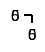

In [3]:
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", 
              "plot_config", "topo", "source_functions_1p3"]

for mod in my_modules:
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *
from source_functions_1p3 import *

In [4]:
project_dir = "/Users/octaviacrompton/Dropbox/FullCSWOF/Tests/"
cases = [d for d in os.listdir(project_dir) if 
            ('DS_Store' not in d) and ('figures' not in d)]


---
## Research overview

This notebook investigates three related questions about roughness scaling in overland flow over heterogeneous (vegetated) hillslopes using SWOF simulations:

**(a) Why is $n_e < \langle n \rangle$?**  
The equivalent roughness $n_e$ inferred from hydrograph matching is consistently lower than the spatial arithmetic mean $\langle n \rangle$. The analytical correction factor and friction-slope decomposition identify the physical mechanisms behind this.

**(b) How does $n_e / \langle n \rangle$ vary with vegetation spatial pattern?**  
The ratio depends on how vegetation is arranged — its spatial scale ($\sigma$), anisotropy, orientation (along-slope vs. along-contour), and cover fraction $f_V$.

**(c) Does this dependence change with storm characteristics?**  
We test whether pattern effects are stable across storm intensities ($p$) and durations ($t_r$), using tracer-based hydrograph analysis.

**(d) How does this compare to composite channels**

In [5]:

# ── Variable naming / display labels ──────────────────────────────────────────
# Shared labels and helpers live in src/labels.py
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
from labels import (
    updates, rename, renameit,
    format_name as _format_name_raw,
)

# Wrap format_name so callers don't need to pass `names` explicitly
def format_name(fld, updates=updates):
    return _format_name_raw(fld, names, updates=updates)


## Load simulations

In [6]:
def load_output(out_dir, load = 1):
    path = os.path.join(out_dir, "sim_list.json")

    # read_summary(sim_list[0], default, out_dir)
    with open(path, "r") as read_file:
        sim_list = json.load(read_file)

    path = os.path.join(out_dir, "default.json")

    with open(path, "r") as read_file:
        default = json.load(read_file)   

    if load == 1:
        summary, badlist = load_summary(sim_list, default, out_dir)    
    else:
        summary, badlist = get_summary(sim_list, default, out_dir)
    
    return summary, badlist, sim_list



In [50]:
out_dir = os.path.join(project_dir, "runaround_smooth")
summary, badlist, sim_list = load_output(out_dir, load = 1)


In [51]:
for key in summary.index:
    sim = summary.loc[key]
    summary.loc[key, 'fV'] = (sim.veg.mean())

In [52]:

print_input_params(sim_list)

rain intensity, p (cm/hr): 5, 8
rain duration, tr (min): 30, 60
hillslope length, l (m): 200
vegetation n, alpha_v: 0.2
vegetation Ksat, Ks_v (cm/hr): 3
Slope angle, So: 0.01
vegetation lengthscale, sigma: 1, 2, 3, 4, 5
vegetation fraction, fV: 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9
aniso: -2, 1, 2


(<Figure size 700x300 with 1 Axes>, <Axes: xlabel='minutes', ylabel='cm/hr'>)

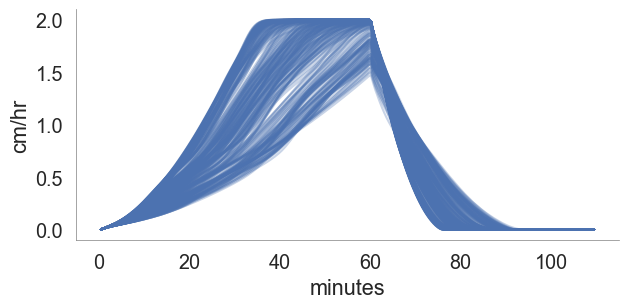

In [53]:
plot_hydrographs(summary.query("tr == 60 and l == 200 and p == 5"))

In [54]:

out_dir_eq = os.path.join(project_dir, "runaround_equiv_smooth")
summary_equiv, badlist_equiv, sim_list_equiv = load_output(out_dir_eq, load = 0)


p-5,tr-30,l-200,fV-0.0,alpha_b-0.03,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.031,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.032,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.034,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.035,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.036,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.037,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.038,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.04,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.041,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.042,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.043,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.045,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.046,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.047,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.048,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.049,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.051,Ks_v-3,So-0.01
p-5,tr-30,l-200,fV-0.0,alpha_b-0.052,Ks_v-3,So-0.01
p-5,tr-30,l-20

In [55]:
print_input_params(sim_list_equiv)

rain intensity, p (cm/hr): 5, 8
rain duration, tr (min): 30, 60
hillslope length, l (m): 200
vegetation fraction, fV: 0.
bare soil n, alpha_b: 0.03, 0.031, 0.032, 0.034, 0.035, 0.036, 0.037, 0.038, 0.04, 0.041, 0.042, 0.043
, 0.045, 0.046, 0.047, 0.048, 0.049, 0.051, 0.052, 0.053, 0.054, 0.056, 0.057, 0.058
, 0.059, 0.06, 0.062, 0.063, 0.064, 0.065, 0.066, 0.068, 0.069, 0.07, 0.071, 0.073
, 0.074, 0.075, 0.076, 0.077, 0.079, 0.08, 0.081, 0.082, 0.083, 0.085, 0.086, 0.087
, 0.088, 0.09, 0.091, 0.092, 0.093, 0.094, 0.096, 0.097, 0.098, 0.099, 0.1, , 0.102
, 0.103, 0.104, 0.105, 0.107, 0.108, 0.109, 0.11, 0.111, 0.113, 0.114, 0.115, 0.116
, 0.117, 0.119, 0.12, 0.121, 0.122, 0.124, 0.125, 0.126, 0.127, 0.128, 0.13, 0.131
, 0.132, 0.133, 0.134, 0.136, 0.137, 0.138, 0.139, 0.14, 0.142, 0.143, 0.144, 0.145
, 0.147, 0.148, 0.149, 0.15, 0.151, 0.153, 0.154, 0.155, 0.156, 0.158, 0.159, 0.16
, 0.161, 0.162, 0.164, 0.165, 0.166, 0.167, 0.168, 0.17, 0.171, 0.172, 0.173, 0.175
, 0.176, 0.177, 0.178,

In [56]:
summary = add_terms(summary)
summary = add_lengthscales(summary)

In [57]:
# summary = summary.sample(100)

In [58]:
def add_lengthscales(summary):
    """
    """
    import cv2
    for fld in ['patch_LV', 'LV_dist', 'upslope_B', 'upslope_V', 'uB_dist',
                 'patch_WV', 'WV_dist', 'patch_LB', 'LB_dist', 'L_dc_dist']:
        
        summary = insert_fld(summary,fld)

    for key in summary.index:
        
        sim = summary.loc[key]
        
        summary.at[key,"fV"] = sim.veg.mean()

        patch_LV, upslope_B = get_patchL(sim.veg, 1000) 
        
        summary.at[key,"patch_LV"] = patch_LV # [patch_LV> 0].mean()
        
        summary.at[key,"LV_dist"] =  unweight_array(patch_LV)
        summary.at[key,"LV"] =  np.mean(summary.at[key,"LV_dist"])    
                
        summary.at[key,"upslope_B"] = upslope_B
        uB = unweight_array(upslope_B)
        summary.at[key,"uB_dist"] = uB
        summary.at[key,"uB"] = np.mean(uB)
 
        patch_WV, patch_right_B = get_patchL(sim.veg.T, 1000) 
        summary.at[key,"patch_WV"] = patch_WV
        WV = unweight_array(patch_WV) 
        summary.at[key,"WV_dist"] = WV
        summary.at[key,"WV_avg"] = np.mean(WV)       
        
        patch_LB, upslope_V = get_patchL(1-sim.veg, 1000)   
        L_dc = patch_LB[:, -1]
        summary.at[key,"L_dc_dist"] =  L_dc
        summary.at[key,"L_dc"] = L_dc.mean()     
        summary.at[key,"L_dc>0"] = L_dc[L_dc>0].mean()     
        summary.at[key,"patch_LB"] = patch_LB
        summary.at[key,"upslope_V"] = upslope_V

        # bare soil length, including 0s
        summary.at[key,"LB_w"] = patch_LB[patch_LB>0].mean() # weighted 
        summary.at[key,"LB_wv"] = patch_LB.mean() # weighted with vegetation
        
        # bare soil length, unweighted
        LB = unweight_array(patch_LB) 
        summary.at[key,"LB_dist"] = LB
        summary.at[key,"LB"] = np.mean(LB) # unweighted
        
        # along slope fraction that is transition from bare soil to vegetated
        bare_to_veg = (np.diff(sim.veg, 1) == -1)
        summary.at[key, "bare_to_veg"] = bare_to_veg.mean()
        
        # # along slope fraction that is transition from vegetated to bare soil
        veg_to_bare = (np.diff(sim.veg, 1) == 1)  
        summary.at[key,"veg_to_bare"] = veg_to_bare.mean()

        # # fraction of hillslope available for lateral/transverse flow
        edge = (sim.veg - cv2.erode(sim.veg, np.ones([1,3]), 1)) 
        summary.at[key,'edge'] =  edge.sum()/sim.veg.sum()
    

    return summary

In [59]:
summary = add_Reynolds_numbers(summary)
summary = add_Re_all(summary)

In [60]:
# uniform domain simulations
summary_equiv = add_terms(summary_equiv)
summary_equiv = add_lengthscales(summary_equiv)

In [61]:
# 
summary = insert_fld(summary, 'equiv_hydro')     # hydrogaph in equivalent roughness
summary = insert_fld(summary, 'equiv_hydro_IF') # gridded infiltration fraction

In [62]:
for c, key in enumerate(summary.index):
    
    sim  = summary.loc[key]

    # Subset library of uniform runs to those matching geometry/forcing for this sim
    subset = summary_equiv.query("l == {0} and p == {1} and tr == {2} ".format(sim.l, sim.p, sim.tr))
    
    # --- Match full hydrograph by RMSE (align lengths defensively) ---
    nhydro = len(sim.hydro)
    # RMSE between this heterogeneous run and each candidate uniform run (min over common length)
    errors = [np.mean((sim.hydro[:min(nhydro, len(hydro))] - 
                       hydro[:min(nhydro, len(hydro))])**2)**0.5 for hydro in subset.hydro]
    ind = np.where(errors == np.min(errors))[0][0]  # argmin; first if ties
        
    # Equivalent roughness = alpha_b of the best‐matching uniform run
    r_equiv = subset.iloc[ind].alpha_b
    summary.loc[key, 'r_equiv'] = r_equiv 
    # IF misfit (diagnostic): absolute difference at the best hydrograph match
    summary.loc[key, 'IF_err'] = np.abs(sim.IF - subset.iloc[ind].IF)
   
    # Store the matched uniform hydrograph (as a list for consistency)
    summary.at[key, 'equiv_hydro'] = list(subset.query("alpha_b == {0}".format(r_equiv)).iloc[0].hydro)
    assert(len(subset.query("alpha_b == {0}".format(r_equiv))) > 0)
    
    # Normalized hydrograph error (scale by peak of this heterogeneous hydrograph)
    summary.loc[key, 'hydro_err'] = np.min(errors)/sim.hydro.max()    

    # --- Identifiability around the minimum: narrow bands of near‐optimal RMSE ---
    # 2% window around the minimum RMSE
    r_equiv = subset.iloc[np.where(errors < np.min(errors)*1.02)[0]].alpha_b.mean()
    summary.loc[key, 'r_equiv2_hydro'] = r_equiv 
    r_std =   subset.iloc[np.where(errors < np.min(errors)*1.02)[0]].alpha_b.std()
    summary.loc[key, 'r_std2'] = r_std  
    
    # 5% window around the minimum RMSE
    r_equiv = subset.iloc[np.where(errors < np.min(errors)*1.05)[0]].alpha_b.mean()
    summary.loc[key, 'r_equiv5_hydro'] = r_equiv 
    r_std =   subset.iloc[np.where(errors < np.min(errors)*1.05)[0]].alpha_b.std()
    summary.loc[key, 'r_std5'] = r_std      

    # --- Split the hydrograph into rise/fall segments and match separately ---
    i_tr = sim.i_tr  # transition index (split point)

    # Rise‐phase RMSE (up to i_tr)
    errors = [np.mean((sim.hydro[:i_tr] - hydro[:i_tr])**2)**0.5 for hydro in subset.hydro]
    r_equiv = subset.iloc[np.where(errors == np.min(errors))[0][0]].alpha_b
    summary.loc[key, 'r_equiv_rise'] = r_equiv 
        
    # Fall‐phase RMSE (from i_tr to the end of common length)
    # NOTE: if you intended a slice, prefer hydro[i_tr : min(nhydro, len(hydro))] (single colon).
    errors_fall = [np.mean((sim.hydro[i_tr:min(nhydro,len(hydro))] - 
                            hydro[i_tr:min(nhydro,len(hydro))])**2)**0.5 for hydro in subset.hydro]
    r_equiv = subset.iloc[np.where(errors_fall == np.min(errors_fall))[0][0]].alpha_b
    summary.loc[key, 'r_equiv_fall'] = r_equiv 
    
    # --- Equivalent roughness by calibrating a scalar index (IF) instead of the full curve ---
    errors_IF = [np.mean((sim.IF - IF)**2)**0.5 for IF in subset.IF]    
    r_equiv = subset.iloc[np.where(errors_IF == np.min(errors_IF))[0][0]].alpha_b
    summary.loc[key, 'r_equiv'] = r_equiv 
    summary.at[key, 'equiv_hydro_IF'] = list(subset.query("alpha_b == {0}".format(r_equiv)).iloc[0].hydro)
    
    r_equiv = subset.iloc[np.where(errors_IF < np.min(errors_IF)*1.05)[0]].alpha_b.mean()
    summary.loc[key, 'r_equiv5'] = r_equiv 
    
    r_equiv = subset.iloc[np.where(errors_IF < np.min(errors_IF)*1.02)[0]].alpha_b.mean()    
    summary.loc[key, 'r_equiv2'] = r_equiv     

    
# --- Vegetation fraction bookkeeping ---
summary['fV'] = summary.veg.apply(lambda v: round(float(v.mean()), 3))

# Parse original fV from index label for comparison (assumes stable naming like '...,fV-0.3,...')
summary['fVo'] = [float(name.split(',')[2].split("-")[1]) for name in summary.index]



_These cells read `sim.hc` (depth) and/or `sim.vc` (velocity) arrays from each row of `summary`. They must run **before** the slim-data step below._

### Series decomposition

_Why is $n_e < \langle n \rangle$? The correction factor and term-by-term $S_f$ decomposition._

---

#### Method 1 — Correction factor (`<U>_CF`, `<h>_CF`)

Applies the point-scale kinematic-wave formula at every cell **as if the full slope length $l$ were the upslope distance** for all cells, then spatially averages:

$$\langle U \rangle_\text{CF} = \frac{5}{7} \left\langle \left[ \frac{1}{n} \left( q_0\, l \right)^{2/3} S_0^{1/2} \right]^{3/5} \right\rangle$$

$$\langle h \rangle_\text{CF} = \frac{5}{8} \left\langle \left( q_0\, l\, n\, S_0^{-1/2} \right)^{3/5} \right\rangle$$

where $q_0 = (p - K_s)/3.6\times10^5\,\mathrm{m\,s^{-1}}$ is net rainfall intensity. This treats the roughness pattern as a purely lateral (cross-slope) effect and ignores each cell's actual position along the slope.

---

#### Method 2 — Slope-integrated (`<Ua>`, `<ha>`)

Integrates the kinematic-wave formula **along each slope column** using the correct upslope distance $x$ at each position, then row-averages and normalises by $l$:

$$\langle U_a \rangle = \frac{1}{l} \left\langle \int_0^l \left[ \frac{(q_0\, x)^{2/3}}{n(x)} S_0^{1/2} \right]^{3/5} dx \right\rangle$$

$$\langle h_a \rangle = \frac{1}{l} \left\langle \int_0^l \left( q_0\, x\; n(x)\, S_0^{-1/2} \right)^{3/5} dx \right\rangle$$

This correctly accounts for flow accumulation: cells near the top of the slope carry less discharge than those at the bottom, so $n(x)$ is weighted by its actual hydraulic influence.

---

**Effective roughness** is then back-calculated from either estimate as $n_e = \langle h \rangle^{2/3} S_0^{1/2} / \langle U \rangle$. The ratio $n_e / \langle n \rangle$ quantifies how much the spatial organisation of roughness shifts the bulk hydraulic resistance relative to the arithmetic mean.

In [63]:
def integrate_U_across(r_2d, m, So, p, dx=2):
    """
    Compute ∫ ((p x)^m / r(x) S_o^w)^(1/(m+1)) dx along axis=1 of a 2D array.

    Parameters:
    - r_2d: 2D numpy array (x along axis=1)
    - m: exponent in the formula
    - So: slope term
    - p: scaling constant
    - dx: spacing along the x axis

    Returns:
    - 1D numpy array of integrals along axis=1 (one per row)
    """
    x = np.arange(r_2d.shape[1]) * dx / 3.6e5
    x_matrix = np.expand_dims(x, axis=0) * p  # shape (1, n) to broadcast across rows

    with np.errstate(divide='ignore', invalid='ignore'):
        expr = (x_matrix ** m / r_2d) ** (1 / (m + 1))
        expr[np.isnan(expr)] = 0
        expr[np.isinf(expr)] = 0

    integral = np.trapezoid(expr, dx=dx, axis=1)
    return 5/7*integral * So ** (0.5 / (m + 1))


def integrate_h_across(r_2d, m, So, p, dx=2):
    """
    Compute ∫ ((x * r(x) * p * S_o^-w)^(1/(m+1)) dx along axis=1 of a 2D array.

    Parameters:
    - r_2d: 2D numpy array (x along axis=1)
    - m: exponent in the formula
    - So: slope term
    - p: scaling constant
    - dx: spacing along the x axis

    Returns:
    - 1D numpy array of integrals along axis=1 (one per row)
    """
    x = np.arange(r_2d.shape[1]) * dx / 3.6e5

    x_matrix = np.expand_dims(x, axis=0) * p  # shape (1, n) to broadcast across rows

    with np.errstate(divide='ignore', invalid='ignore'):
        expr = (x_matrix * r_2d) ** (1 / (m + 1.))
        expr[np.isnan(expr)] = 0
        expr[np.isinf(expr)] = 0

    integral = np.trapezoid(expr, dx=dx, axis=1)
    return 5/8*integral * So ** (-0.5 / (m + 1.))

In [64]:
## Series decomposition

for key in summary.index:
    sim = summary.loc[key]

    # ---- indices & constants
    i_tr = int(sim.i_tr)
    dx   = float(sim.dx)
    g    = 9.81

    # ---- Manning n field (float, safe copy)
    veg = np.asarray(sim.veg)
    n = veg.astype(float).copy()
    n[veg == 1] = float(sim.alpha_v)
    n[veg == 0] = float(sim.alpha_b)

    # ---- time-slice arrays (float)
    h_t = np.asarray(sim.hc, dtype=float)[i_tr]  # (ny, nx)
    U_t = np.asarray(sim.vc, dtype=float)[i_tr]  # (ny, nx)

    # ---- central difference (aligns with midpoints)
    dUdx  = (U_t[:, 2:] - U_t[:, :-2]) / (2 * dx)  # (ny, nx-2)
    U_mid = U_t[:, 1:-1]                           # (ny, nx-2)

    # ---- diagnostics
    summary.loc[key, 'n_misc'] = np.nanmean(h_t**(1/6) * n**0.5)
    summary.loc[key, 'n_exp1'] = np.mean((n**1.5))**(2/3)
    summary.loc[key, 'n_exp2'] = np.mean((n**2))**(1/2)
    
    summary.loc[key, 'n_tr']   = np.nanmean(h_t**(2/3)) * (sim.So**0.5) / np.nanmean(U_t)
    summary.loc[key, 'Cd']     = g * np.nanmean(h_t) * sim.So / np.nanmean(U_t**2)    
    summary.loc[key, 'Cd_misc']     = 9.8*np.nanmean(h_t**(-1/3.)*n**0.5)


    # ---- correction-factor study
    summary.loc[key, '<U>_CF'] = (5/7) * np.nanmean((
        (1/n) * ((sim.p - sim.Ks_v)/3.6e5 * sim.l)**(2/3) * sim.So**0.5)**(3/5))
    summary.loc[key, '<h>_CF'] = (5/8) * np.nanmean(
        ((sim.p - sim.Ks_v)/3.6e5 * sim.l * n / sim.So**0.5)**(3/5))

    # ---- cross-section integrals (use sim.dx)
    try:
        Ua = 5/7*integrate_U_across(n, 2/3, sim.So, sim.p - sim.Ks_v, dx=dx)/sim.l
        ha = 5/8*integrate_h_across(n, 2/3, sim.So, sim.p - sim.Ks_v, dx=dx)/sim.l
        summary.loc[key, '<Ua>'] = np.nanmean(Ua)
        summary.loc[key, '<ha>'] = np.nanmean(ha)
        summary.loc[key, '<na>'] = (np.nanmean(ha))**(2/3) / np.nanmean(Ua) * sim.So**0.5
    except NameError:
        summary.loc[key, '<Ua>'] = np.nan
        summary.loc[key, '<ha>'] = np.nan
        summary.loc[key, '<na>'] = np.nan

    # ---- means
    U_bar = float(np.nanmean(U_t))
    h_bar = float(np.nanmean(h_t))
    n_bar = float(np.nanmean(n))
    
    summary.loc[key, 'n_exp3']  = np.mean(h_t**(5/3))/(np.mean(h_t**(5/3)/n) )
    summary.loc[key, 'n_exp4']  = np.mean(n)
    summary.loc[key, 'n_exp6']  = np.mean(h_t**(1/3)*n) / np.mean(h_t**(1/3))
    summary.loc[key, 'n_exp7']  = np.mean(h_t**(6)*n) / np.mean(h_t**(1./6))    
    summary.loc[key, 'n_exp8']  = 1 /np.mean(n**(-1))         

    summary.loc[key, '<n>']     = n_bar
    summary.loc[key, '<U>']     = U_bar
    summary.loc[key, '<h>']     = h_bar
    summary.loc[key, '<U>/<h>'] = U_bar / h_bar
    summary.loc[key, 'n_gmean'] = gmean(n.ravel())

    summary.loc[key, '<n2>']    = float(np.nanmean(n**2))
    summary.loc[key, '<n>2']    = n_bar**2

    # ---- direct mean friction slope (ground truth)
    Sf_direct = float(np.nanmean(n**2 * h_t**(-4/3) * U_t**2))
    summary.loc[key, '<Sf>']        = Sf_direct
    summary.loc[key, '<Sf>_direct'] = Sf_direct  # convenient alias

    # ---- fluctuations
    Up = U_t - U_bar
    hp = h_t - h_bar
    np_ = n - n_bar

    dUp_dx = (Up[:, 2:] - Up[:, :-2]) / (2 * dx)

    # time derivative of <U>
    Um = np.nanmean(np.asarray(sim.vc), axis=(1, 2))
    summary.loc[key, 'd<U>/dt'] = np.gradient(Um, float(sim['dt']))[i_tr]

    # velocity gradient summaries
    summary.loc[key, '<dU/dx>']     = float(np.nanmean(dUdx))
    summary.loc[key, '<U dU/dx>']   = float(np.nanmean(U_mid * dUdx))
    summary.loc[key, '<U><dU/dx>']  = float(np.nanmean(U_mid) * np.nanmean(dUdx))
    summary.loc[key, '<Up dUp/dx>'] = float(np.nanmean(Up[:, 1:-1] * dUp_dx))
    summary.loc[key, '<Up2>']       = float(np.nanmean(Up**2))
    summary.loc[key, '<hp2>']       = float(np.nanmean(hp**2))
    summary.loc[key, '<nU>']        = float(np.nanmean(n*U_t))
    summary.loc[key, '<n><U>']      = float(U_bar*n_bar)
    summary.loc[key, '<np Up>']     = float(np.nanmean(np_*Up))
    summary.loc[key, '<h^2/3>']     = float(np.nanmean(h_t**(2/3)))    
    summary.loc[key, '<Uh>']        = float(np.nanmean(h_t*U_t))        

    # depth gradients (same stencil)
    dh_dx  = (h_t[:, 2:] - h_t[:, :-2]) / (2 * dx)
    dhp_dx = (hp[:, 2:] - hp[:, :-2]) / (2 * dx)
    summary.loc[key, '<dh/dx>']  = float(np.nanmean(dh_dx))
    summary.loc[key, '<dhp/dx>'] = float(np.nanmean(dhp_dx))

    # ---- prefactor: <n2><h>^-4/3
    summary.loc[key, '<n2><h>^-4/3'] = np.nanmean(n**2) * (h_bar ** (-4/3))

    # ---- second-moment stats
    summary.loc[key, '<np2>']   = float(np.nanmean(np_**2))
    summary.loc[key, '<np Up>']  = float(np.nanmean(np_ * Up))
    summary.loc[key, '<Up hp>'] = float(np.nanmean(Up * hp))
    summary.loc[key, '<np hp>'] = float(np.nanmean(np_ * hp))

    []
    # --- mean unit discharge <q> via three forms (diagnostic)
    # Use a wet mask to avoid tiny/zero depths
    hmin = 1e-4
    wet = (h_t > hmin) & np.isfinite(U_t) & np.isfinite(n)
    
    # ===== Second-order prediction for n_e/<n> using n and h only =====
    # r = (n - <n>)/<n>,   eta = (h - <h>)/<h>
    r   = np_ / n_bar                          # n' / <n>
    eta = hp / h_bar                           # h' / <h>

    r2    = float(np.nanmean(r**2))            # <r^2>
    eta2  = float(np.nanmean(eta**2))          # <eta^2>
    r_eta = float(np.nanmean(r * eta))         # <r eta>

    # Store the components
    summary.loc[key, '<r2>']     = r2
    summary.loc[key, '<eta2>']   = eta2
    summary.loc[key, '<r eta>']  = r_eta


    # 2nd-order approximation for effect ratio (n_e / <n>)
    er_Qpred2 = 1/(1.0 + r2 + (5/9)*eta2 - (5/3)*r_eta)
    summary.loc[key, 'effect_ratio_Qpred2']   = er_Qpred2               # predicted effect ratio
    summary.loc[key, 'n_e_Qpred2']  = er_Qpred2 * n_bar       # predicted n_e 

    
    # ===== U-based effective roughness (exact + 2nd-order) =====
    # ups = U'/<U>
    ups   = Up / U_bar
    ups2  = float(np.nanmean(ups**2))          # <ups^2>
    r_ups = float(np.nanmean(r * ups))         # <r * ups>
    eta_ups = float(np.nanmean(eta * ups))         # <eta * ups>

    # Store U-based second moments
    summary.loc[key, '<ups2>']    = ups2
    summary.loc[key, '<r ups>']   = r_ups
    summary.loc[key, '<eta ups>']   = eta_ups    
    
    # Exact effect ratio from identity:
    # (n_e / <n>) = < (n/<n>)^(3/2) * (U/<U>)^(5/2) >^(2/3)
    bracket = (n / n_bar)**(3/2) * (U_t / U_bar)**(5/2)
    effect_ratio_U = float(np.nanmean(bracket[wet]))**(2/3)
    summary.loc[key, 'effect_ratio_U'] = effect_ratio_U
    summary.loc[key, 'n_e_U']          = effect_ratio_U * n_bar

    # 2nd-order approximation:
    # n_e/<n> ≈ 1 + (1/4)<r^2> + (5/4)<ups^2> + (5/2)<r ups>
    effect_ratio_Upred2 = 1.0 + 0.25*r2 + 1.25*ups2 + 2.5*r_ups
    summary.loc[key, 'effect_ratio_Upred2'] = effect_ratio_Upred2
    summary.loc[key, 'n_e_Upred2']          = effect_ratio_Upred2 * n_bar
    

    # (1) Direct: q = U h
    q_direct = float(np.nanmean((U_t * h_t)[wet]))

    # (2) h-based Manning form: q = S0^{1/2} * h^{5/3} / n
    q_hform = float(sim.So**0.5 * np.nanmean((h_t[wet]**(5/3)) / n[wet]))

    # (3) U-based identity form: q = S0^{-3/4} * n^{3/2} * U^{5/2}
    q_uform = float((sim.So**(-3/4)) * np.nanmean((n[wet]**(3/2)) * (U_t[wet]**(5/2))))

    # Store means
    summary.loc[key, '<q>_direct'] = q_direct
    summary.loc[key, '<q>_hform']  = q_hform
    summary.loc[key, '<q>_uform']  = q_uform

    # Absolute differences
    summary.loc[key, 'dq_h_minus_direct'] = q_hform - q_direct
    summary.loc[key, 'dq_u_minus_direct'] = q_uform - q_direct

    # ============================
    #  Second-order series only
    # ============================

    # ---- h power factors (prefactors for <h> exponents)
    h_pref0 = h_bar**(-4/3)   # <h>^{-4/3}
    h_pref1 = h_bar**(-7/3)   # <h>^{-7/3}
    h_pref2 = h_bar**(-10/3)  # <h>^{-10/3}

    # ---- binomial coefficients for (h_bar + h')^{-4/3} up to O(eta^2)
    c0 = 1.0
    c1 = - 4.0/3.0
    c2 = 14.0/9.0

    # ---- mixed moments needed up to quadratic order
    Up2   = np.nanmean(Up**2)
    np2   = np.nanmean(np_**2)
    Uphp  = np.nanmean(Up * hp)   # <U' h'>
    nphp  = np.nanmean(np_ * hp)  # <n' h'>
    hp2   = np.nanmean(hp**2)     # <(h')^2>
    npUp  = np.nanmean(np_ * Up)  # <n' U'>

    # ---- T0 .. T2 groups (strictly up to total 2nd order)
    # T0 = <n^2 U^2> up to O(2): base + <U'^2> + <n'^2> + 4<n><U><n'U'>
    T0 = (
        (n_bar**2)*(U_bar**2)
        + (n_bar**2)*Up2
        + (U_bar**2)*np2
        + 4.0*n_bar*U_bar*npUp
    )

    # T1 = <n^2 U^2 h'> up to O(2): only terms with one prime in numerator and one in h'
    T1 = (
        2.0*(n_bar**2)*U_bar*Uphp   # depth–velocity covariance, from ∂^2f/∂U∂h term
        +2.0*n_bar*(U_bar**2)*nphp  # depth–roughness covariance, from ∂^2f/∂n∂h term
    )

    # T2 = <n^2 U^2 (h')^2> up to O(2): base*(h')^2
    T2 = (n_bar**2)*(U_bar**2)*hp2

    # ---- assemble contributions with prefactors
    Sf_T0 = h_pref0 * T0
    Sf_T1 = c1 * h_pref1 * T1
    Sf_T2 = c2 * h_pref2 * T2

    # ---- store individual terms (what was missing)
    summary.loc[key, '<Sf>_nbar2_Ubar2'] = h_pref0 * (n_bar**2) * (U_bar**2)
    summary.loc[key, '<Sf>_nbar2_Up2']   = h_pref0 * (n_bar**2) * Up2
    summary.loc[key, '<Sf>_Ubar2_np2']   = h_pref0 * (U_bar**2) * np2
    summary.loc[key, '<Sf>_cross_nU']    = h_pref0 * (4.0 * n_bar * U_bar * npUp)

    summary.loc[key, '<Sf>_C_Uphp_lin']   = c1 * h_pref1 * (2.0 * (n_bar**2) * U_bar * Uphp)
    summary.loc[key, '<Sf>_C_nphp_lin']   = c1 * h_pref1 * (2.0 * n_bar * (U_bar**2) * nphp)

    # ---- totals (quadratic series)
    summary.loc[key, '<Sf>_T0'] = float(Sf_T0)
    summary.loc[key, '<Sf>_T1'] = float(Sf_T1)
    summary.loc[key, '<Sf>_T2'] = float(Sf_T2)

    Sf_exp2 = float(Sf_T0 + Sf_T1 + Sf_T2)
    summary.loc[key, '<Sf>_exp2'] = Sf_exp2
    summary.loc[key, '<Sf>_direct_minus_exp2'] = Sf_direct - Sf_exp2

    # ============================
    #  Hybrid estimator (quadratic)
    # ============================
    # hmin and wet already defined above — reuse with tighter threshold (depth only)
    wet  = h_t > hmin

    # Dimensionless depth fluctuation about arithmetic mean
    eta = np.where(wet, hp / h_bar, np.nan)
    summary.loc[key, 'eta_max'] = float(np.nanmax(np.abs(eta)))
    summary.loc[key, 'eta_mean'] = float(np.nanmean(np.abs(eta)))    
    summary.loc[key, 'eta_rms'] = float(np.sqrt(np.nanmean(eta**2)))

    # Quadratic series and exact per-cell weights
    w_series2 = c0 + c1*eta + c2*(eta**2)
    w_exact   = np.where(wet, (1.0 + eta)**(-4.0/3.0), np.nan)  # exact weight

    # Blend: series where |eta| <= thresh, else exact
    thresh = 0.8
    mask_series = np.abs(eta) <= thresh
    w_hybrid2 = np.where(mask_series, w_series2, w_exact)
    summary.loc[key, 'wet'] = wet.sum()
    summary.loc[key, 'eta'] = mask_series.sum()

    
    Sf_series2 = h_pref0 * float(np.nanmean((n**2) * (U_t**2) * w_series2))  # pure quadratic series
    Sf_hybrid2 = h_pref0 * float(np.nanmean((n**2) * (U_t**2) * w_hybrid2))  # hybrid quadratic

    # Store with clearer names
    summary.loc[key, '<Sf>_series2']            = Sf_series2
    summary.loc[key, 'series2_err']             = Sf_direct - Sf_series2
    summary.loc[key, '<Sf>_hybrid_quad']        = Sf_hybrid2
    summary.loc[key, 'hybrid_quad_err']         = Sf_direct - Sf_hybrid2
    summary.loc[key, 'hybrid_quad_frac_series'] = float(np.nanmean(mask_series))
    summary.loc[key, '<Sf>_direct_wet'] = float(np.nanmean((n**2) * (U_t**2) * (h_t**(-4/3)) * wet))

    # Nondimensional (quadratic) diagnostics (optional)
    ND0 = float(np.nanmean((n**2) * (U_t**2) * (eta**0)))
    ND1 = float(np.nanmean((n**2) * (U_t**2) * (eta**1)))
    ND2 = float(np.nanmean((n**2) * (U_t**2) * (eta**2)))
    Sf_nd_T0 = h_pref0 * (c0 * ND0)
    Sf_nd_T1 = h_pref0 * (c1 * ND1)
    Sf_nd_T2 = h_pref0 * (c2 * ND2)
    summary.loc[key, '<Sf>_nd_T0'] = Sf_nd_T0
    summary.loc[key, '<Sf>_nd_T1'] = Sf_nd_T1
    summary.loc[key, '<Sf>_nd_T2'] = Sf_nd_T2
    summary.loc[key, '<Sf>_nd_sumK2'] = Sf_nd_T0 + Sf_nd_T1 + Sf_nd_T2
    summary.loc[key, 'err_nd_K2'] = Sf_direct - summary.loc[key, '<Sf>_nd_sumK2']

    # ---------- Hybrid-weighted numerator decomposition (2nd-order in numerator)
    # Weight each numerator piece by w_hybrid2, then average; all share h_bar^{-4/3}
    mean_w = float(np.nanmean(w_hybrid2))

    # components analogous to classic T0 split, but hybrid-weighted
    Sf_hyb_base  = h_pref0 * (n_bar**2) * (U_bar**2) * mean_w
    Sf_hyb_Up2   = h_pref0 * (n_bar**2) * float(np.nanmean(w_hybrid2 * (Up**2)))
    Sf_hyb_np2   = h_pref0 * (U_bar**2) * float(np.nanmean(w_hybrid2 * (np_**2)))
    Sf_hyb_cross = h_pref0 * (4.0*n_bar*U_bar) * float(np.nanmean(w_hybrid2 * (np_ * Up)))

    summary.loc[key, '<Sf>_hyb_base']  = Sf_hyb_base
    summary.loc[key, '<Sf>_hyb_Up2']   = Sf_hyb_Up2
    summary.loc[key, '<Sf>_hyb_np2']   = Sf_hyb_np2
    summary.loc[key, '<Sf>_hyb_cross'] = Sf_hyb_cross

    # summed hybrid numerator pieces (diagnostic) — should be close to <Sf>_hybrid_quad
    summary.loc[key, '<Sf>_hyb_num_sum'] = Sf_hyb_base + Sf_hyb_Up2 + Sf_hyb_np2 + Sf_hyb_cross

    # T0 under hybrid weighting (sum of the 4 numerator pieces you computed)
    Sf_T0_hyb = float(Sf_hyb_base + Sf_hyb_Up2 + Sf_hyb_np2 + Sf_hyb_cross)

    summary.loc[key, '<Sf>_T0_hyb']   = Sf_T0_hyb

    
summary['r_ratio'] =  summary['alpha_b'] / summary['alpha_v'] 
summary['effect'] =  summary['<n>'] - summary['r_equiv5'] 
summary['effect_ratio'] =  summary['r_equiv5']/summary['<n>'] 
summary['effect_ratio_geom'] =  summary['r_equiv5']/summary['n_gmean']

# ── Hydrograph-based equivalents (use r_equiv5_hydro in place of r_equiv5) ─────
summary['effect_hydro']       = summary['<n>'] - summary['r_equiv5_hydro']
summary['effect_ratio_hydro'] = summary['r_equiv5_hydro'] / summary['<n>']

# ── Toggle: set USE_HYDRO = True to make 'effect_ratio' use hydrograph-based n_e
USE_HYDRO = False
if USE_HYDRO:
    summary['effect']       = summary['effect_hydro']
    summary['effect_ratio'] = summary['effect_ratio_hydro']
    print("Using r_equiv5_hydro as the default equivalent roughness")
else:
    print("Using r_equiv5 (IF-based) as the default equivalent roughness")

summary['<U>^2/<Up^2>'] = (summary['<U>']**2/ summary['<Up2>'])    


# --- Discharge-based n_e prediction (vectorised via apply) ---
def ne_from_Q(sim):
    """
    Uses the identity:
        (1/n_e) * <h>^{5/3} = < h^{5/3} / n >
    ⇒  n_e = <h>^{5/3} / < h^{5/3} / n >
    computed at the analysis time slice i_tr.
    """
    i = int(sim.i_tr)

    # depth field at i_tr
    h = np.asarray(sim.hc, dtype=float)[i]   # (ny, nx)

    # rebuild Manning n from veg + (alpha_b, alpha_v) exactly as in your loop
    veg = np.asarray(sim.veg)                # 0/1
    n = veg.astype(float).copy()
    n[veg == 1] = float(sim.alpha_v)
    n[veg == 0] = float(sim.alpha_b)

    h_bar = float(np.nanmean(h))
    if not np.isfinite(h_bar) or h_bar == 0:
        return np.nan

    inv_ne = float(np.nanmean((1./ n) * (h / h_bar)**(5.0/3.0)))
    return np.nan if not np.isfinite(inv_ne) or inv_ne == 0 else 1.0 / inv_ne

# Discharge-based predictions (overwrites per-row values computed in loop above)
summary['n_e_Q'] = summary.apply(ne_from_Q, axis=1)
summary['effect_ratio_Q']  = summary['n_e_Q'] / summary['<n>']    # predicted effect ratio n_e/<n>

# Observed vs predicted vectors (handy if you want quick checks)
er_obs = summary['effect_ratio'].to_numpy(float)     # observed from hydrograph (r_equiv5/<n>)
er_hat = summary['effect_ratio_Q'].to_numpy(float)   # discharge-based predicted effect ratio

ne_obs = summary['r_equiv5'].to_numpy(float)         # observed n_e from hydrograph calibration
ne_hat = summary['n_e_Q'].to_numpy(float)            # discharge-based predicted n_e


Using r_equiv5 (IF-based) as the default equivalent roughness


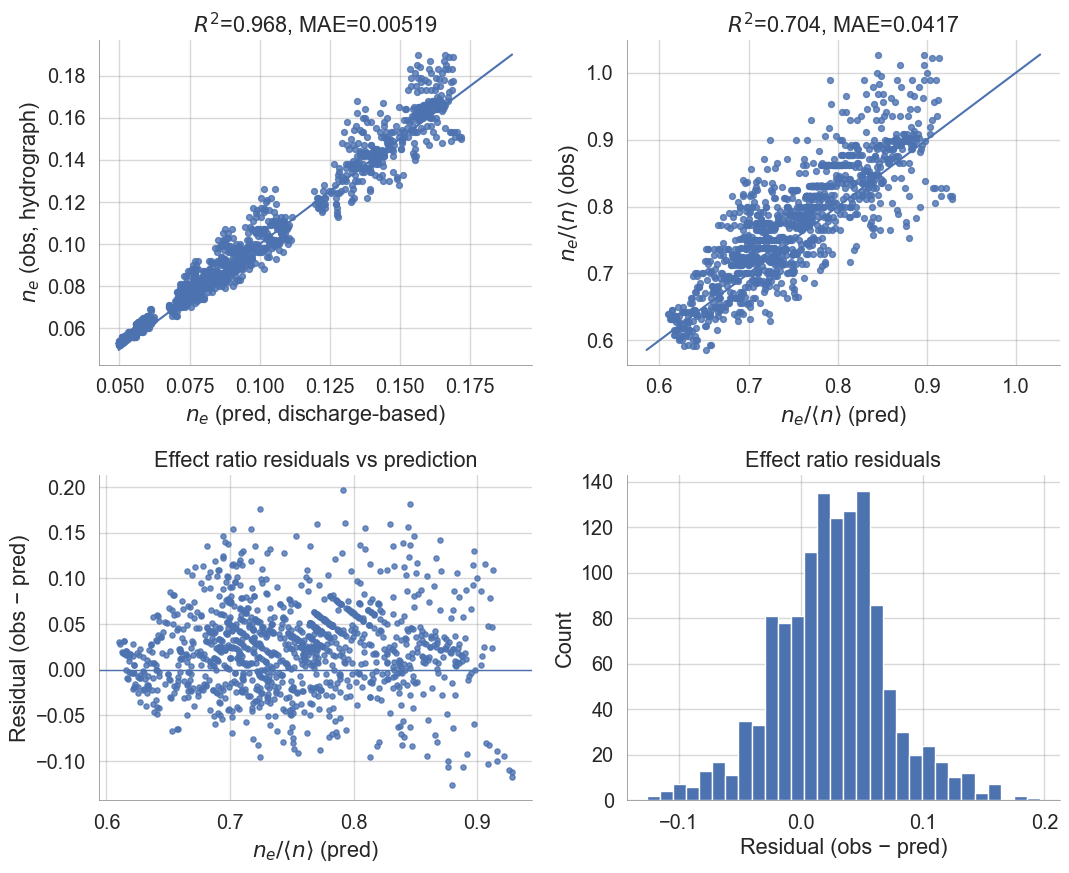

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Discharge-based n_e prediction (per time slice i_tr) ---
def ne_from_Q(sim):
    i = int(sim.i_tr)
    h = np.asarray(sim.hc, float)[i]          # (ny, nx)
    veg = np.asarray(sim.veg)                 # (ny, nx) 0/1
    n = veg.astype(float)
    n[veg == 1] = float(sim.alpha_v)
    n[veg == 0] = float(sim.alpha_b)
    inv_ne = np.nanmean((1.0 / n) * (h / np.nanmean(h))**(5/3))
    return 1.0 / inv_ne

summary['n_e_Qpred'] = summary.apply(ne_from_Q, axis=1)
summary['er_Qpred']  = summary['n_e_Qpred'] / summary['<n>']   # predicted effect ratio

# observed (from hydrograph) — adjust names if yours differ
er_obs = summary['effect_ratio'].to_numpy(float)
er_hat = summary['er_Qpred'].to_numpy(float)

ne_obs = summary['r_equiv5'].to_numpy(float)
ne_hat = summary['n_e_Qpred'].to_numpy(float)

# finite masks
m_er = np.isfinite(er_obs) & np.isfinite(er_hat)
m_ne = np.isfinite(ne_obs) & np.isfinite(ne_hat)

def r2(x, y):
    if np.sum(np.isfinite(x) & np.isfinite(y)) < 3:
        return np.nan
    return float(np.corrcoef(x, y)[0, 1]**2)

def mae(x, y):
    return float(np.nanmean(np.abs(x - y)))

# --- 2) Plots: predicted vs observed + residual diagnostics ---
fig, axs = plt.subplots(2, 2, figsize=(11, 9))
(ax1, ax2), (ax3, ax4) = axs

# A: n_e (pred vs obs)
x, y = ne_hat[m_ne], ne_obs[m_ne]
ax1.scatter(x, y, s=18, alpha=0.8)
mn, mx = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
ax1.plot([mn, mx], [mn, mx])  # 1:1
ax1.set_xlabel(r"$n_e$ (pred, discharge-based)")
ax1.set_ylabel(r"$n_e$ (obs, hydrograph)")
ax1.set_title(f"$R^2$={r2(x,y):.3f}, MAE={mae(x,y):.3g}")
ax1.grid(True, alpha=0.3)

# B: effect ratio (pred vs obs)
x, y = er_hat[m_er], er_obs[m_er]
ax2.scatter(x, y, s=18, alpha=0.8)
mn, mx = np.nanmin([x.min(), y.min()]), np.nanmax([x.max(), y.max()])
ax2.plot([mn, mx], [mn, mx])  # 1:1
ax2.set_xlabel(r"$n_e/\langle n\rangle$ (pred)")
ax2.set_ylabel(r"$n_e/\langle n\rangle$ (obs)")
ax2.set_title(f"$R^2$={r2(x,y):.3f}, MAE={mae(x,y):.3g}")
ax2.grid(True, alpha=0.3)

# C: residuals vs predicted (effect ratio)
res = (er_obs[m_er] - er_hat[m_er])
ax3.scatter(er_hat[m_er], res, s=14, alpha=0.8)
ax3.axhline(0, linewidth=1)
ax3.set_xlabel(r"$n_e/\langle n\rangle$ (pred)")
ax3.set_ylabel("Residual (obs − pred)")
ax3.set_title("Effect ratio residuals vs prediction")
ax3.grid(True, alpha=0.3)

# D: residual histogram (effect ratio)
ax4.hist(res[~np.isnan(res)], bins=30)
ax4.set_xlabel("Residual (obs − pred)")
ax4.set_ylabel("Count")
ax4.set_title("Effect ratio residuals")
ax4.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


### Correction factor: cross-section flow predictions

_Re-examines cross-section velocity and depth profile predictions underlying the analytical correction factor._


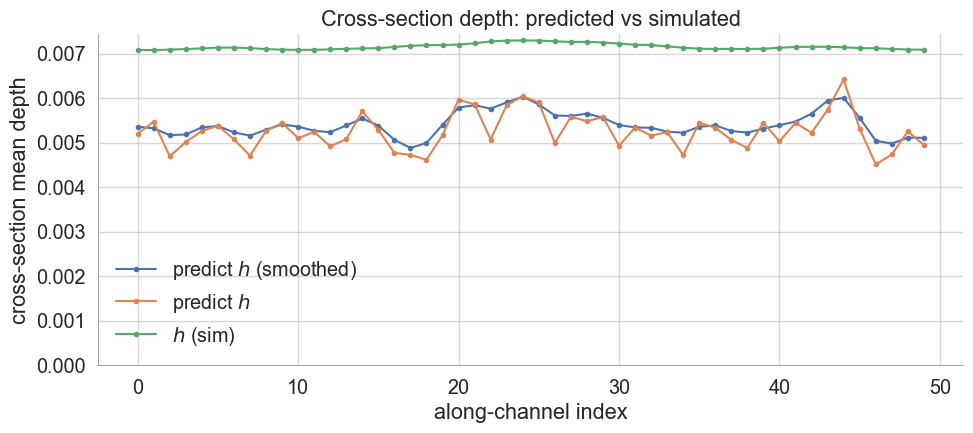

In [66]:
sim = summary.iloc[3]
# ---------- cross-section depth: predicted vs simulated ----------

veg = np.asarray(sim.veg)
n = veg.astype(float).copy()
n[veg == 1] = float(sim.alpha_v)
n[veg == 0] = float(sim.alpha_b)

from scipy.ndimage import gaussian_filter1d
smoothed = gaussian_filter1d(np.asarray(n, dtype=float), sigma=1, axis=0)

# Cross-section mean depth along the channel
hbar = np.asarray(sim.hc, dtype=float)[int(sim.i_tr)].mean(1)
S_eff = float(sim.So) - np.gradient(hbar, float(sim.dx))

ha_eff = integrate_h_across(smoothed, .66, S_eff, float(sim.p) - float(sim.Ks_v), dx=float(sim.dx))
h_pred_eff =  ha_eff / float(sim.l)

dx = float(getattr(sim, "dx", 2.0))
ha = integrate_h_across(n, .66, float(sim.So), float(sim.p) - float(sim.Ks_v), dx=dx)
h_pred = np.asarray(ha, dtype=float) / float(sim.l)
h_obs  = np.asarray(sim.hc, dtype=float)[int(sim.i_tr)].mean(1)


nmin = min(len(h_pred), len(h_obs))
h_pred = h_pred[:nmin]
h_obs  = h_obs[:nmin]

# (B) cross-section depth
fig, axes = plt.subplots(1, figsize=(10, 4.6))
ax = axes
ax.plot(h_pred_eff, ".-", label="predict $h$ (smoothed)")
ax.plot(h_pred, ".-", label="predict $h$")
ax.plot(h_obs,  ".-", label="$h$ (sim)")
ax.set_ylim(bottom=0)
ax.set_xlabel("along-channel index")
ax.set_ylabel("cross-section mean depth")
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, loc="best")
ax.set_title("Cross-section depth: predicted vs simulated")

plt.tight_layout()




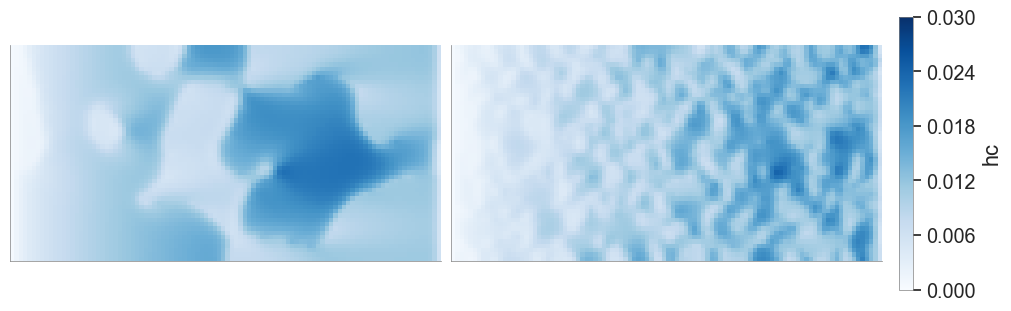

In [67]:
try:
    sim = summary.query("fV == 0.6 and sigma == 5 and tr == 60 and p == 5 and aniso == 1").iloc[0]

    sim2 = summary.query("fV == 0.6 and sigma == 1 and tr == 60 and p == 5 and aniso == 1").iloc[0]
except:
    sim = summary.query("fV == 0.6 and stripe_count == 4 and tr == 60 and p == 5 and aniso == 1").iloc[0]

    sim2 = summary.query("fV == 0.6 and stripe_count == 10 and tr == 60 and p == 5 and aniso == 1").iloc[0]    
    
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

vmin, vmax = 0, 0.03
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)

im0 = axes[0].imshow(sim.hc[sim.i_tr],  cmap="Blues", norm=norm)
im1 = axes[1].imshow(sim2.hc[sim.i_tr], cmap="Blues", norm=norm)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

# one colorbar spanning both panels
cbar = fig.colorbar(im1, ax=axes, location="right", fraction=0.035, pad=0.02)
cbar.set_label("hc")
cbar.locator = MaxNLocator(5)
cbar.update_ticks()
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

In [68]:
# summary['<Sf>_variance_terms']   = summary['<Sf>_nbar2_Up2'] + summary['<Sf>_Ubar2_np2']
# summary['<Sf>_hp_terms']   = summary['<Sf>_C_Uphp_lin']   + summary['<Sf>_C_nphp_lin']
# summary['effect_ratio_T0'] =  1 + summary['<r2>'] + summary['<ups2>'] + 4*summary['<r ups>']

In [69]:
cols = [c for c in summary.columns if '<Sf>' in c]
cols.sort()

In [70]:
(summary['<Up2>']/summary['<U>']**2).describe()
# summary['<hp2>']/summary['<h>']**2

count    1260.000000
mean        0.287974
std         0.091060
min         0.127661
25%         0.200906
50%         0.304654
75%         0.357494
max         0.499269
dtype: float64

## Hydrographs  

In [71]:
 summary.query(" hydro_err < 10  ")['hydro_err']

p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-1,seed-1,fV-0.1,aniso--2    0.005042
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-1,seed-1,fV-0.1,aniso-1     0.005592
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-1,seed-1,fV-0.1,aniso-2     0.003724
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-1,seed-1,fV-0.2,aniso--2    0.007957
p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-1,seed-1,fV-0.2,aniso-1     0.009318
                                                                               ...   
p-8,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-5,seed-3,fV-0.8,aniso-1     0.023520
p-8,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-5,seed-3,fV-0.8,aniso-2     0.017936
p-8,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-5,seed-3,fV-0.9,aniso--2    0.013055
p-8,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-5,seed-3,fV-0.9,aniso-1     0.017755
p-8,tr-60,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-5,seed-3,fV-0.9,aniso-2     0.013320
Name: hydro_err, Length: 1260, dtype: float64

p-5,tr-30,l-200,alpha_v-0.2,Ks_v-3,So-0.01,sigma-1,seed-1,fV-0.4,aniso--2 0.008491921321662023
[0.1 0.2 0.4 0.5 0.6 0.8 0.9]


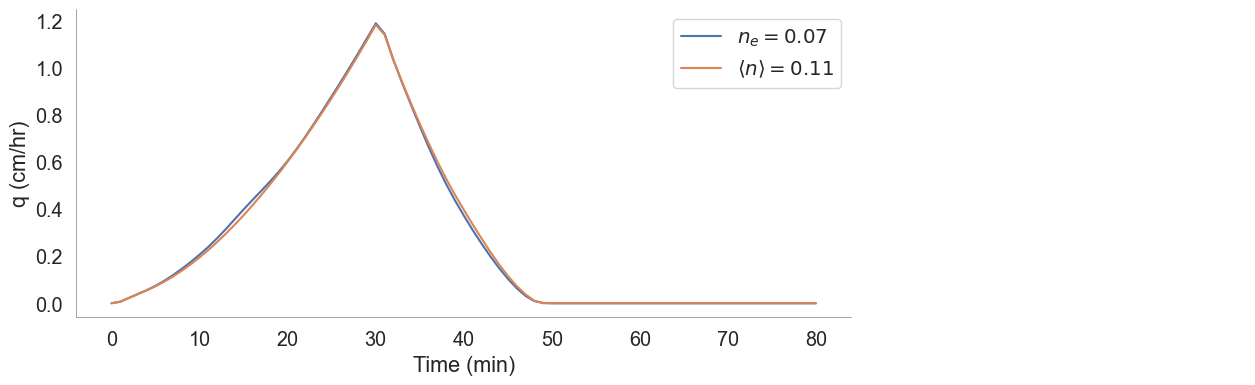

In [73]:
fig, ax = plt.subplots(1, figsize = (10,4))
sim = summary.query(" hydro_err < 1  ").iloc[6]

ax.plot(sim.t/60,sim.hydro,   label = "$n_{e}"+"={0:.2f}$".format(sim.r_equiv))

ax.plot(sim.t[:len(sim.equiv_hydro)]/60, sim.equiv_hydro, 
        label = r"$\langle n \rangle$" +"$={0:.2f}$".format(sim['<n>']))
subset= summary_equiv.query("L == {0} and p == 8".format(sim.L))
for key in subset.index[0:]:
    ax.plot(subset.loc[key].t/60,subset.loc[key].hydro, 'g', alpha = 0.1)
ax.legend()
ax.set_xlabel("Time (min)")
ax.set_ylabel("q (cm/hr)")
ax.text(1.5, 0., ' ', transform=ax.transAxes, ha="left", va="top",
            fontsize = 18, style = 'italic');
print (sim.name, sim.hydro_err)

print(summary.fV.unique())

[0.1 0.2 0.4 0.5 0.6 0.8 0.9]


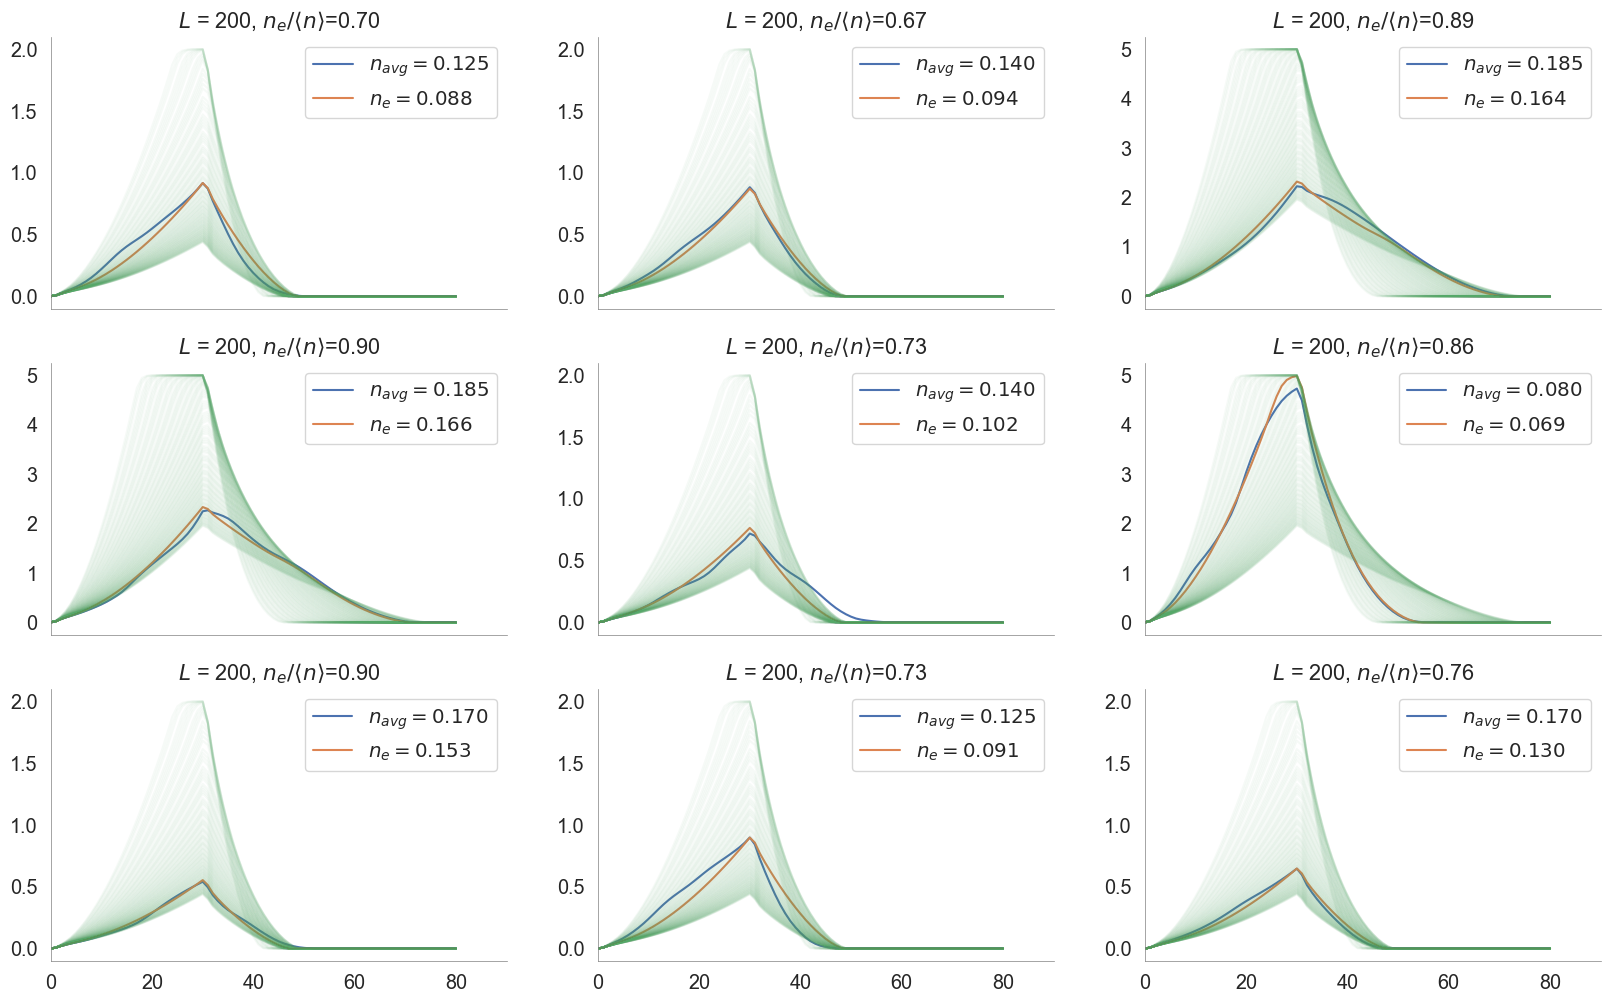

In [74]:
def plot_q_compare(sim, ax):

    ax.plot(sim.t/60,sim.hydro,  
            label = "$n_{avg}$" +"$={0:.3f}$".format(sim['<n>']))
    ax.plot(sim.t[:len(sim.equiv_hydro)]/60, sim.equiv_hydro, 
             label = "$n_{e}"+"={0:.3f}$".format(sim.r_equiv))
    subset = summary_equiv.query("l == {0}  and p == {1} and tr == {2}".format(
        sim.l, sim.p, sim.tr))
    
    for key in subset.index:
        ax.plot(subset.loc[key].t/60,subset.loc[key].hydro, 'g', alpha = 0.05)
    ax.legend()
    
subset = summary.query("hydro_err > 0.02 and tr == 30").sort_values("l").sample(9)   
fig, axes = plt.subplots(3, 3, figsize = (20,12), sharex = True)
axes = axes.ravel()
for i, ax in enumerate(axes):
    sim = subset.iloc[i]
    plot_q_compare(sim, ax)
    ax.set_xlim(0, sim.tr*3)
    ax.set_title(r'$L$ = {0:.0f}, '.format(sim.l) + r'$n_e/\langle n \rangle$'+ r'={0:.2f}'.format(sim.r_equiv/sim['<n>']))

print(summary.fV.unique())

[0.1 0.2 0.4 0.5 0.6 0.8 0.9]


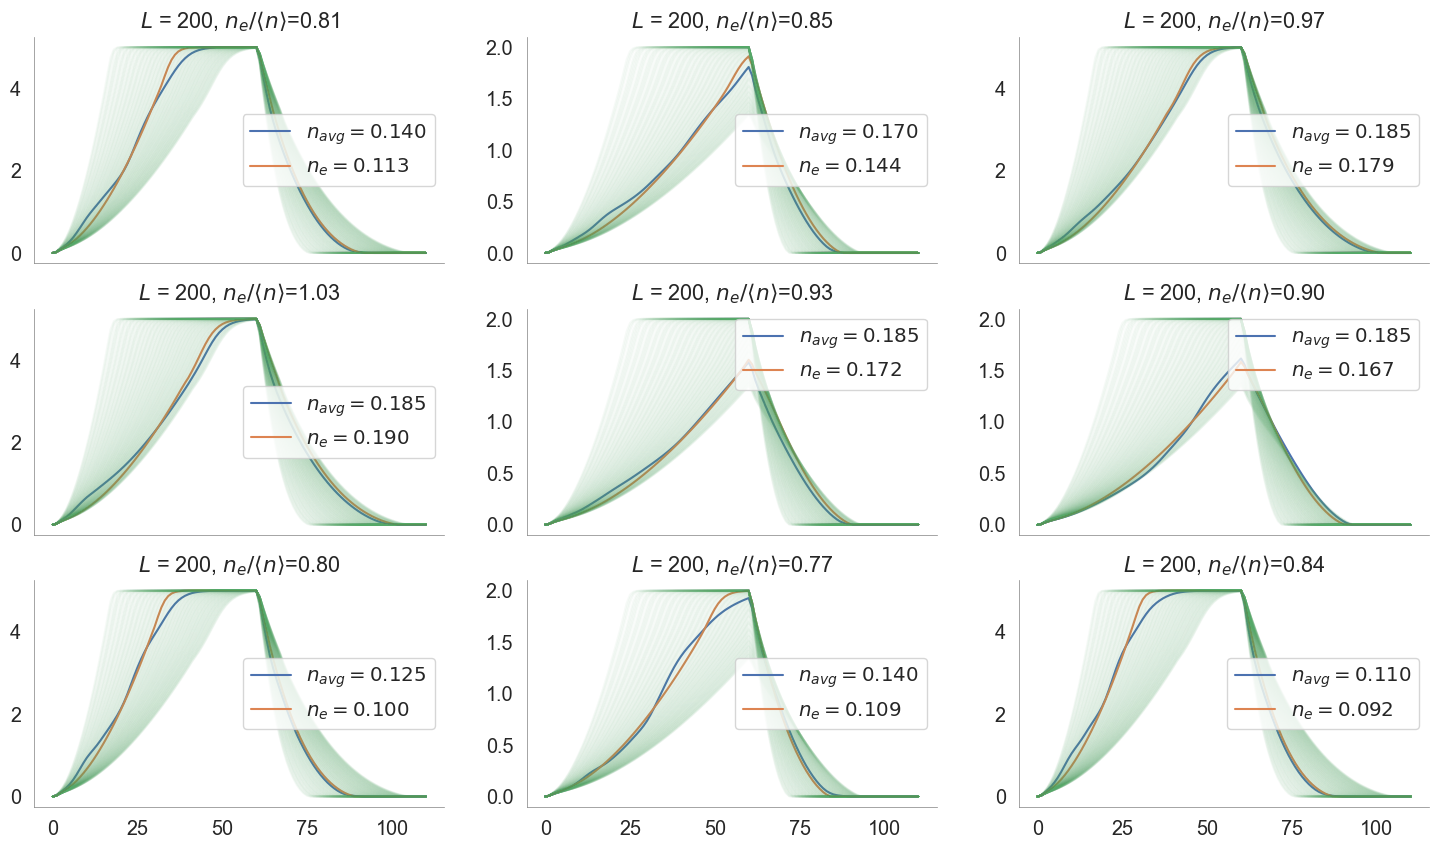

In [75]:
subset = summary.query("hydro_err > 0.02 and hydro_err < 0.1 and tr == 60").sort_values("l").sample(9)   
fig, axes = plt.subplots(3, 3, figsize = (18,10), sharex = True)
axes = axes.ravel()
for i, ax in enumerate(axes):
    sim = subset.iloc[i]
    plot_q_compare(sim, ax)
    #ax.set_xlim(0, sim.tr*2)
    ax.set_title(r'$L$ = {0:.0f}, '.format(sim.l) +
                 r'$n_e/\langle n \rangle$'+ r'={0:.2f}'.format(sim['effect_ratio']))

print(summary.fV.unique())

##  Storm characteristics: add tracers

_Tracer-based analysis to examine how flow routing and roughness scaling depend on storm intensity/duration ($p$, $t_r$)._


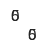

In [76]:
# reload modules
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", "plot_config", 
              "topo", "run_around",
              "source_functions_1p3"]

for mod in my_modules :
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *

from run_around import *
from source_functions_1p3 import *



In [77]:
%%time
from tqdm import tqdm
from multiprocess import Pool


tracer_cols = [ 'y_f', 'y_i', 'x_f', 'x_i', 't_f', 't_i', 'veg_bin',
        'std_x',  't_esc', 'residence', 'length','escape', 'escape_in_domain', 
        'time_to_escape', 'time_to_infiltrate', 'distance']

# params = {"h_min" : 1e-4, "y_min" : 1, "t_min" : 1, 'N' : 2000, "initialize" : 'top'}
params = {"h_min" : 1e-3, "y_min" : 1,  "t_min" : 1, 'N' : 1000}
tracer_name = ",".join(["{0}-{1}".format(key, val) for key,val in params.items() ])
print (tracer_name)

tracer_path = os.path.join(out_dir, tracer_name + ".pkl")
run_tracers = not os.path.exists(tracer_path)
print("Running tracers:", run_tracers, "(file exists)" if not run_tracers else "(no file found)")

def parallel_tracers(key):

    sim = summary.loc[key]  

    if sim.Tbound == 4:
        periodic = 1
    else: 
        periodic = 0
        
    if 't_scale' not in params.keys():
        params.update({"t_scale" : 1})
        t_scale = 1

        
    if 'initialize' not in params.keys():
        params.update({"initialize" : False})
        initialize = False
    
    if sim.Tbound == 4:
        periodic = 1
    else: 
        periodic = 0
            
    positions, recap = integrate_positions(sim, N = params['N'],  initialize = params['initialize'], 
        t_min = params['t_min'],  y_min = params['y_min'], h_min = params['h_min'], 
        t_scale = params['t_scale'], periodic = periodic)
    
    for key, item in params.items():
        
        recap[key]= item

    for fld in tracer_cols: 
        recap[fld] = positions[fld]    

    return recap

if run_tracers:
    
    max_pool = 8
    
    with Pool(max_pool) as p:
        pool_outputs = list(
            tqdm(
                p.imap(parallel_tracers,
                      summary.index),
                total=len(summary)
            )
        )    

    paired = pd.concat(pool_outputs)
    print(paired.shape)

    tracers = pd.DataFrame()
    tracer_cols = pool_outputs[0].index
    for fld in tracer_cols:
        tracers = insert_fld(tracers,fld)

    for i, key in enumerate(summary.index):
        tracers.loc[key] = pool_outputs[i]
        
    tracers.to_pickle(tracer_path)

    shutil.copy("/Users/octaviacrompton/Projects/roughness-scale/swof_code/source_functions_1p3.py", out_dir  + "/code/" + tracer_name + "_source_1p3.py" );        
    print ("saving: " + tracer_name)
else:
    tracers = pd.read_pickle(tracer_path)
    print ("reading: " +  tracer_name)
    
save_cols = ['scenario', 'r', 'Re_all', 'tr', 'p', 'fV', 'Ks_v', 
        'sigma', 'phi_veg', 'l', 'L',  'C', 'infl_frac']

summary[[col for col in save_cols if col in summary]].to_pickle(
    out_dir + "/summary_abrev.pkl")    

# tracers = pd.read_pickle(out_dir + "/" + tracer_name + ".pkl")

try:
    summary = delete_tracers(summary, tracers)
    summary = add_tracers(summary, tracers)

    
except:
    summary = add_tracers(summary, tracers)


h_min-0.001,y_min-1,t_min-1,N-1000
Running tracers: True (no file found)


100%|██████████| 1260/1260 [07:42<00:00,  2.73it/s]


(51660,)
saving: h_min-0.001,y_min-1,t_min-1,N-1000
CPU times: user 5.15 s, sys: 1.53 s, total: 6.68 s
Wall time: 7min 48s


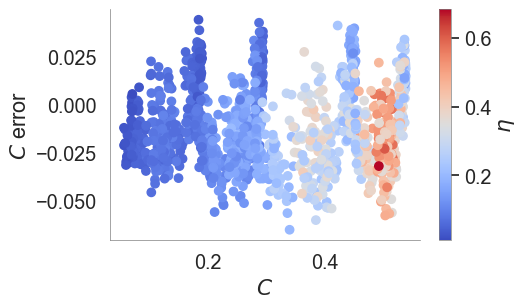

In [83]:
# Tracer diagnostics: scatter of C error vs infiltration fraction, colored by curve
cfld = 'curve'
subset = summary.query("L > 0")
plt.scatter(1- subset.infl_frac, (subset.tracer_err  ), c = subset[cfld], 
            cmap = "coolwarm")

plt.xlabel("$C$");
plt.ylabel("$C$ error");

plt.colorbar(label = format_name(cfld));



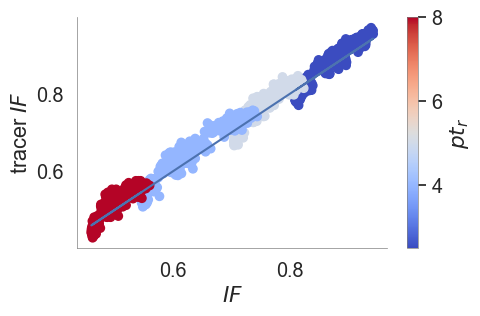

In [84]:
# More tracer diagnostics: scatter of tracer IF vs flow IF, colored by p*tr
summary[r'$p t_r$'] = summary['tr']*summary['p']/60
cfld = r'$p t_r$'
subset = summary
plt.scatter(subset.IF, (subset.tracer_IF), c = subset[cfld], 
            cmap = "coolwarm")

plt.plot(subset.IF, (subset.IF))
plt.xlabel("$IF$");
plt.ylabel("tracer $IF$");

plt.colorbar(label = (cfld));

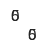

In [86]:
# reload modules
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", "plot_config", 
              "topo", "run_around",
              "source_functions_1p3"]


for mod in my_modules :
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *

from run_around import *
from source_functions_1p3 import *

sim = summary.query("curve > 0. ").iloc[0]
positions, recap = integrate_positions(sim, N = 500)

AttributeError: 'Axes3D' object has no attribute 'w_xaxis'

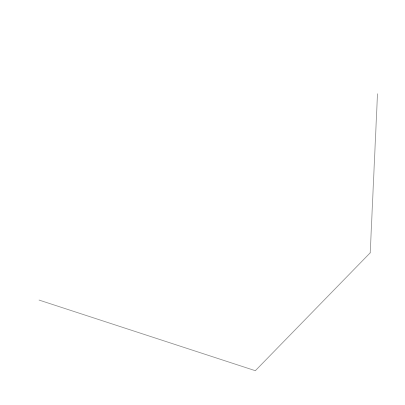

In [87]:


plot_3D_trajectories(sim, positions, ax = '', 
                     escape = 'b', trapped = 'b', alpha = 0.2,
                     min_curve = 0.0, point = 0, 
                     ucut = 1, dcut = 0);


## Utility — Slim dataframes for downstream analysis


In [88]:
# Quick + simple: list the largest variables in your current environment.
# - Handles numpy/pandas/xarray/torch specially; everything else via getsizeof.
# - No deep inspection; fast and concise.

import sys, inspect

def _size_bytes(obj):
    try:
        import xarray as xr
    except Exception:
        xr = None
    try:
        import torch
    except Exception:
        torch = None

    # Common scientific types
    if isinstance(obj, np.ndarray):
        return obj.nbytes
    if isinstance(obj, pd.DataFrame):
        return int(obj.memory_usage(deep=True).sum())
    if isinstance(obj, pd.Series):
        return int(obj.memory_usage(deep=True))
    if xr is not None:
        if isinstance(obj, xr.DataArray):
            return int(obj.nbytes)
        if isinstance(obj, xr.Dataset):
            return int(sum(v.nbytes for v in obj.data_vars.values()))
    if torch is not None and isinstance(obj, torch.Tensor):
        try:
            return int(obj.element_size() * obj.nelement())
        except Exception:
            pass
    # Fallback
    try:
        return int(sys.getsizeof(obj))
    except Exception:
        return 0

def _shape_or_len(obj):
    for attr in ("shape",):
        if hasattr(obj, attr):
            try:
                return tuple(getattr(obj, attr))
            except Exception:
                pass
    try:
        return len(obj)
    except Exception:
        return None

def memtable(top_n=30, min_mb=1.0, namespace=None):
    """Return a DataFrame of the largest variables (>= min_mb) in `namespace`."""
    if namespace is None:
        # Merge globals + caller locals (best effort)
        frm = inspect.currentframe().f_back
        namespace = {}
        namespace.update(getattr(frm, "f_globals", {}))
        namespace.update(getattr(frm, "f_locals", {}))

    rows = []
    seen = set()
    for name, obj in namespace.items():
        if name.startswith("_"):          # skip privates/dunders
            continue
        oid = id(obj)
        if oid in seen:                   # skip aliases
            continue
        seen.add(oid)
        # skip modules/functions/classes
        if hasattr(obj, "__module__") and str(type(obj)).startswith("<class 'module'"):
            continue
        if callable(obj):
            continue

        sz = _size_bytes(obj)
        mb = sz / (1024**2)
        if mb < min_mb:
            continue
        rows.append({
            "name": name,
            "type": type(obj).__name__,
            "shape/len": _shape_or_len(obj),
            "MB": round(mb, 3),
        })

    if not rows:
        return pd.DataFrame(columns=["name","type","shape/len","MB"])

    df = pd.DataFrame(rows).sort_values("MB", ascending=False).head(top_n).reset_index(drop=True)
    return df

# ---- usage
# Show top 25 variables >= 1 MB
memtable(top_n=25, min_mb=1.0)
# You can then delete big ones and gc.collect() if needed.



,name,type,shape/len,MB
0,summary,DataFrame,"(1260, 336)",419.150
1,summary_equiv,DataFrame,"(564, 168)",172.112
2,paired,Series,"(51660,)",152.865
3,tracers,DataFrame,"(1260, 41)",149.826


In [89]:

def _is_arraylike_3d(obj, min_ndim=3, min_size=0):
    """True if obj behaves like a NumPy array with ndim >= min_ndim and size >= min_size."""
    # xarray.DataArray has .values; fall back gracefully
    try:
        if hasattr(obj, "values") and hasattr(obj, "ndim") and hasattr(obj, "size"):
            arr = obj.values
        elif isinstance(obj, np.ndarray):
            arr = obj
        else:
            return False
        return (arr.ndim >= min_ndim) and (arr.size >= min_size)
    except Exception:
        return False
    
    

def find_3d_array_columns(df: pd.DataFrame, min_ndim=3, min_size=0, sample_rows=50):
    """
    Inspect up to `sample_rows` non-null rows per column to decide if the column
    stores 3D (or higher) arrays of at least `min_size` elements.
    Returns a list of column names to drop and a summary dict.
    """
    # deduplicate column names (duplicate names cause df[col] to return a DataFrame)
    to_check = list(dict.fromkeys(df.columns.tolist()))
    cols_to_drop = []
    report = {}

    # limit scans for speed
    idx = df.index
    if len(idx) > sample_rows:
        idx = df.index[:sample_rows]

    for col in to_check:
        # safe column access: if duplicates remain, take first occurrence as a Series
        col_data = df[col]
        if isinstance(col_data, pd.DataFrame):
            col_data = col_data.iloc[:, 0]

        # quick skip: non-object dtypes rarely store arrays
        if col_data.dtype != "object":
            candidates = col_data.iloc[:min(len(idx), 3)]
        else:
            candidates = col_data.loc[idx]

        found = False
        shapes = []
        for v in candidates:
            if _is_arraylike_3d(v, min_ndim=min_ndim, min_size=min_size):
                # capture a shape string if possible
                try:
                    shp = (v.values.shape if hasattr(v, "values") else v.shape)
                    shapes.append(tuple(shp))
                except Exception:
                    shapes.append(("unknown",))
                found = True
        if found:
            cols_to_drop.append(col)
            report[col] = {"shapes_seen": list({s for s in shapes if s is not None})}

    return cols_to_drop, report

# cols_to_drop, rep = find_3d_array_columns(summary, min_ndim=3, min_size=3)
# summary.drop(columns=cols_to_drop, inplace=True)

# cols_to_drop, rep = find_3d_array_columns(subset, min_ndim=3, min_size=3)
# subset.drop(columns=cols_to_drop, inplace=True)


In [ ]:
# ── Slim dataframes: drop heavy 3-D array columns and save ──────────────────
import gc

slim_path = os.path.join(out_dir, 'summary_slim.pkl')

# Identify columns that hold 3-D (or higher) numpy arrays (hc, vc, etc.)
cols_to_drop, _rep = find_3d_array_columns(summary, min_ndim=3, min_size=3)

# Also drop 2-D spatial arrays
# extra_2d = ['veg', 'equiv_hydro', 'equiv_hydro_IF',
#              'patch_LV', 'patch_WV', 'patch_LB',
#              'LV_dist', 'WV_dist', 'LB_dist',
#              'uB_dist', 'L_dc_dist', 'upslope_B', 'upslope_V']
# cols_to_drop += [c for c in extra_2d
#                   if c in summary.columns and c not in cols_to_drop]

print('Dropping columns:', cols_to_drop)
summary_slim = summary.drop(columns=cols_to_drop, errors='ignore').copy()
summary_slim.to_pickle(slim_path)
print(f'Saved slimmed summary  ->  {slim_path}')
print(f'Shape: {summary_slim.shape}   |   columns: {summary_slim.shape[1]}')

gc.collect()

Dropping columns: ['hc', 'uc', 'vc', 'I']
